In [ ]:
import pandas as pd
from google.colab import files
uploaddes = files.upload()

df = pd.read_csv(next(iter(uploaddes)))

df.head()

Saving European_Bank (1).csv to European_Bank (1) (1).csv


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape
df.info
df.isnull().sum()
df.duplicated().sum()
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()
# check duplicate rows after removing
df.duplicated().sum()

np.int64(0)

In [ ]:
#check unique values in categorical columns
print(df['Geography'].unique())
print(df['Gender'].unique())
print(df['Exited'].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']
[1 0]


In [ ]:
#summary of categorical columns
df[['Geography','Gender','Exited']].describe()

,Exited
count,10000.000000
mean,0.203700
std,0.402769
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
import matplotlib.pyplot as plt
print("Matplotlib Imported")

Matplotlib Imported


In [ ]:
import seaborn as sns
print("Seaborn Imported")

Seaborn Imported


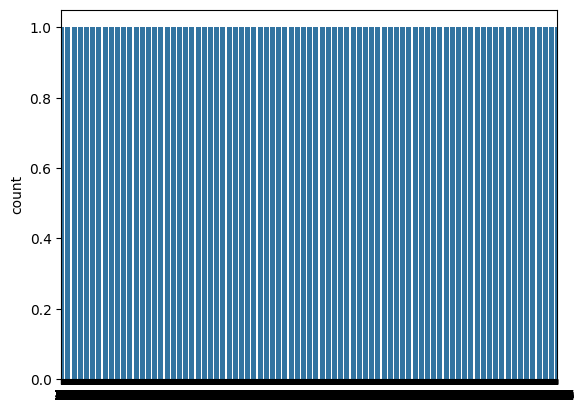

In [ ]:
sns.countplot(df['Exited'])
plt.show()

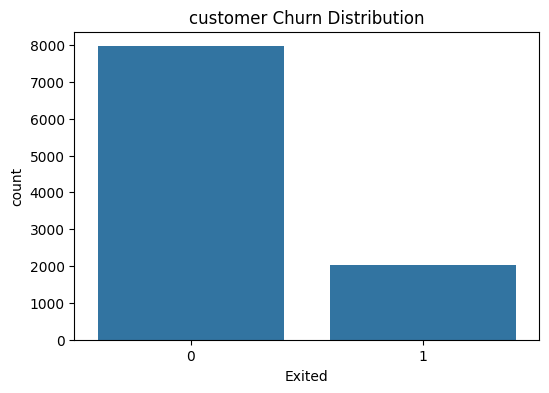

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt .title("customer Churn Distribution")
plt.show()

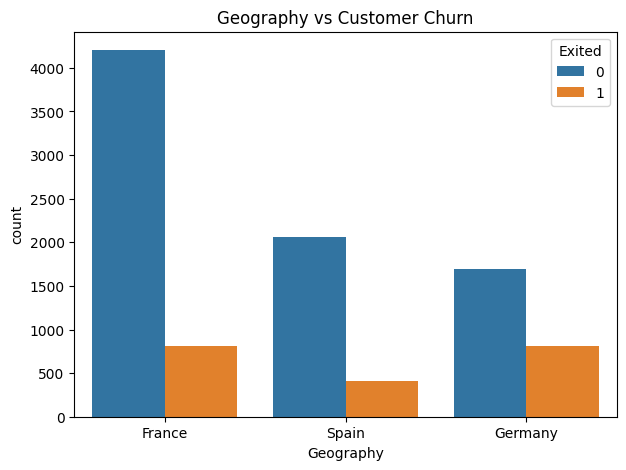

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='Geography',
hue='Exited', data=df)
plt.title("Geography vs Customer Churn")
plt.show()

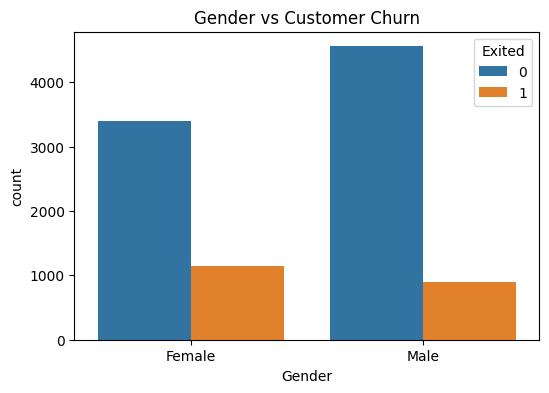

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',
hue='Exited', data=df)
plt.title("Gender vs Customer Churn")
plt.show()

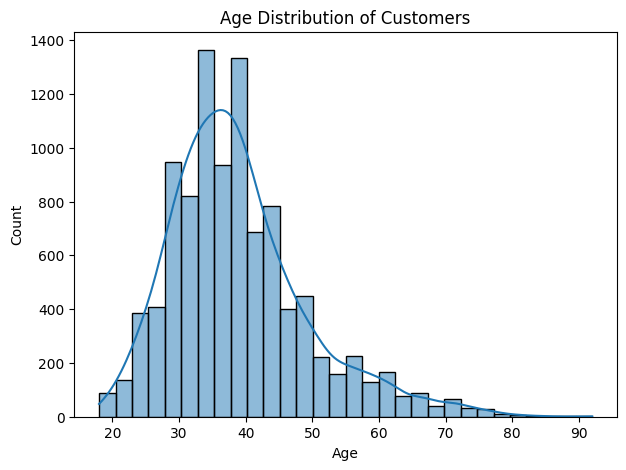

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=30,
kde=True)
plt.title("Age Distribution of Customers")
plt.show()


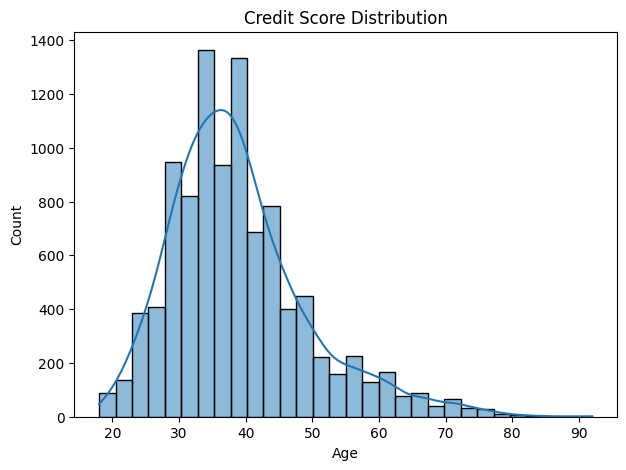

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Age'],bins=30,
kde=True)
plt.title("Credit Score Distribution")
plt.show()

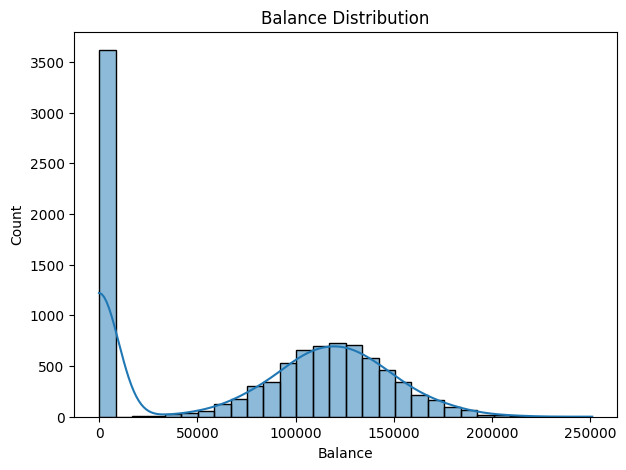

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Balance'],bins=30,
kde=True)
plt.title("Balance Distribution")
plt.show()

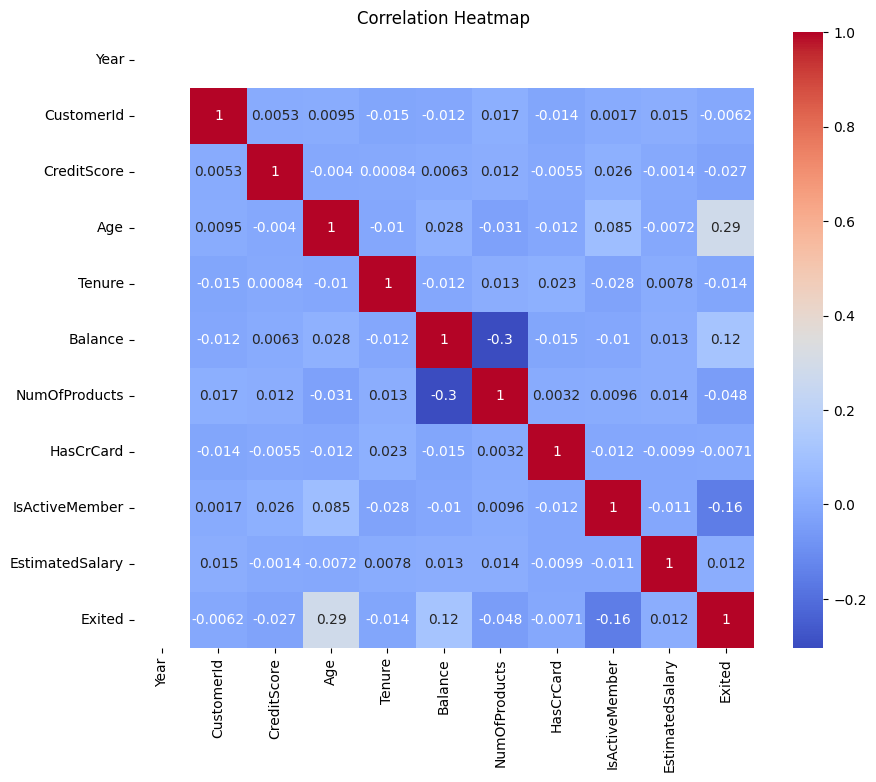

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
df.groupby("Geography")["Balance"].mean()


,Balance
Geography,
France,62092.636516
Germany,119730.116134
Spain,61818.147763


In [ ]:
df.groupby("Gender")["EstimatedSalary"].mean()

,EstimatedSalary
Gender,
Female,100601.541382
Male,99664.576931


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [ ]:
X = df[['CreditScore','Age','Balance','EstimatedSalary']]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


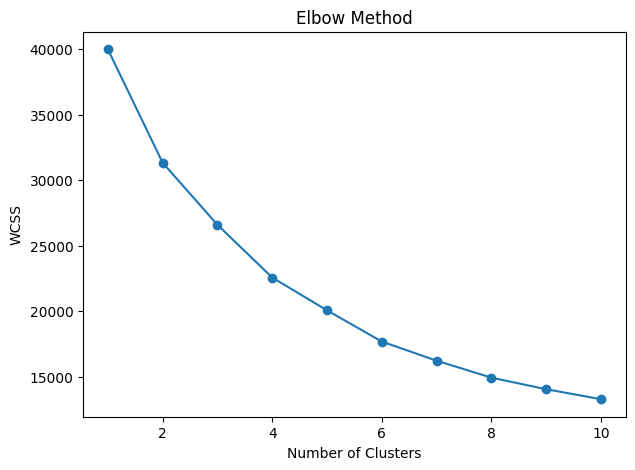

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
2,3325
3,2732
0,2676
1,1267


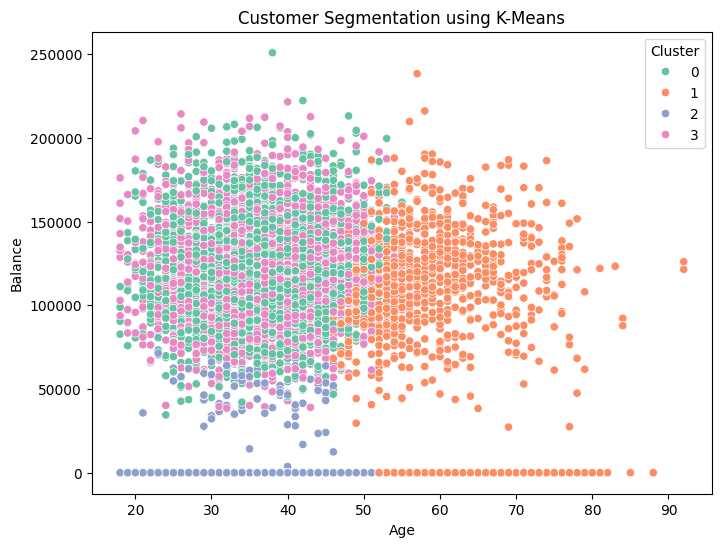

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Balance',
    hue='Cluster',
    palette='Set2'
)
plt.title("Customer Segmentation using K-Means")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'].value_counts()


,count
Cluster,
2,3325
3,2732
0,2676
1,1267


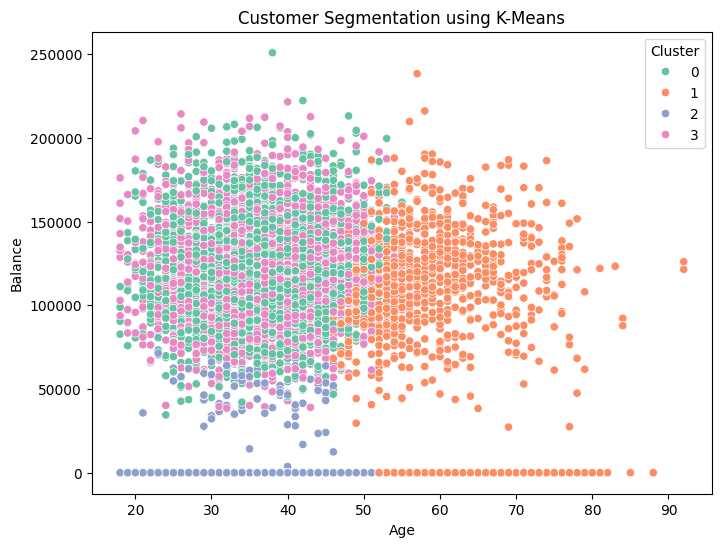

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Balance',
    hue='Cluster',
    palette='Set2'
)
plt.title("Customer Segmentation using K-Means")
plt.xlabel("Age")
plt.ylabel("Balance")
plt.show()


In [ ]:
df.groupby('Cluster')[['Age','Balance','EstimatedSalary','CreditScore']].mean()


,Age,Balance,EstimatedSalary,CreditScore
Cluster,,,,
0,36.121824,122008.383655,49707.232672,655.072870
1,59.292818,80640.615533,96722.190118,649.018942
2,35.742256,1390.845759,99385.665669,648.401203
3,36.086750,121364.654535,151859.989367,649.367496


In [ ]:
X = df.drop(['Exited', 'Cluster'], axis=1)
y = df['Exited']


In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8605


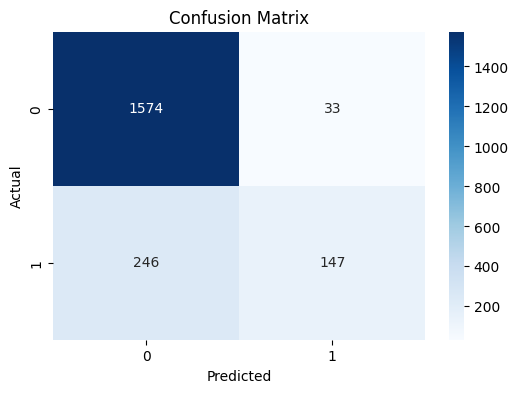

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1607
           1       0.82      0.37      0.51       393

    accuracy                           0.86      2000
   macro avg       0.84      0.68      0.72      2000
weighted avg       0.86      0.86      0.84      2000



In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,Age,0.139382
6,NumOfProducts,0.084589
5,Balance,0.057229
2,CreditScore,0.057201
9,EstimatedSalary,0.056539
1,CustomerId,0.055773
4,Tenure,0.036809
8,IsActiveMember,0.027703
2941,Geography_Germany,0.020018
2943,Gender_Male,0.011910


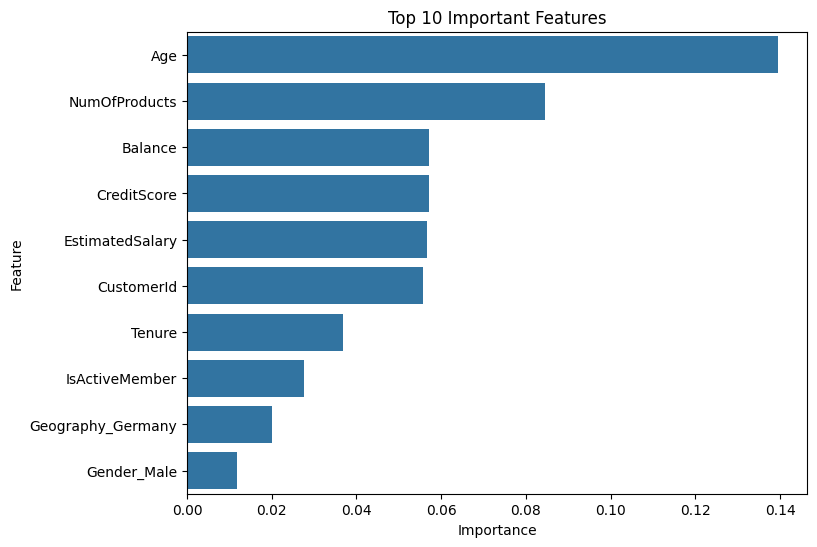

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Important Features")
plt.show()

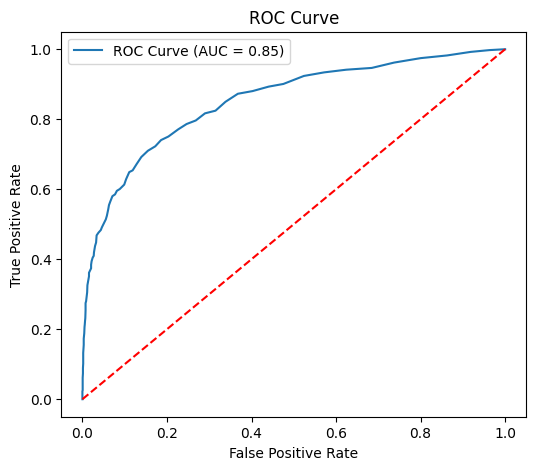

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Business Insights

- Customers with low credit scores have a higher churn risk.
- Middle-aged customers show higher churn than younger customers.
- Geography significantly affects customer churn.
- Customers with higher balances are more likely to churn.
- Estimated salary has a moderate impact on churn.
- Customer segmentation helps identify different customer groups.
- Personalized offers can improve customer retention.
- Loyalty programs can reduce customer churn.
- Predictive analytics helps identify at-risk customers early.
- Data-driven decisions can improve customer satisfaction and profitability.

# Conclusion

This project analyzed customer segmentation and churn patterns in European banking using data analysis, visualization, K-Means clustering, and Random Forest classification. The results identified important factors influencing customer churn and provided valuable business recommendations for improving customer retention